In [1]:
# IN03: API vs MCP, Framework Selection, and Build vs Buy

In [2]:
# Problem statement:
# Imagine Walmart wants to build an AI assistant for store managers across 4,700 stores, handling 50,000+ queries every day.

# A store manager might ask:
#     “Looking at today’s weather and current market demand, what products should I stock more of today?”

# The AI cannot answer this reliably from its training knowledge alone. It needs to connect to live external systems, such as:
#     OpenWeatherMap → current Bengaluru weather
#     Tavily → current market/demand trends
#     Store information → Walmart store details

In [3]:
# three major engineering decisions:
# 1. REST API vs MCP
# 2. Python vs LangChain vs LangGraph
# 3. Build vs Buy

# Design the most scalable, maintainable and cost-effective architecture for a Walmart Retail AI Assistant by choosing the right integration protocol, agent framework, and Build-vs-Buy strategy.

In [4]:
# Load the libraries and keys needed for the full notebook.
# This cell also defines the store we will use in every example.
import os
import json
import time
import requests
from typing import TypedDict
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(override=True)

OPENAI_KEY  = os.getenv('OPENAI_API_KEY')
WEATHER_KEY = os.getenv('OPENWEATHERMAP_API_KEY')
TAVILY_KEY  = os.getenv('TAVILY_API_KEY')

client = OpenAI(api_key=OPENAI_KEY)

# Check whether all required API keys are present before we continue.
missing = [k for k, v in {
    'OPENAI_API_KEY':         OPENAI_KEY,
    'OPENWEATHERMAP_API_KEY': WEATHER_KEY,
    'TAVILY_API_KEY':         TAVILY_KEY,
}.items() if not v]

if missing:
    print(f'WARNING: Missing API keys: {missing}')
    print('Add them to your .env file before running this notebook.')
else:
    print('All required API keys loaded.')

# Fixed store context keeps every comparison in the notebook consistent.
STORE_ID   = 'WMT-2847'
STORE_CITY = 'Bengaluru'
print(f'Store context: {STORE_ID} | {STORE_CITY}, India')

All required API keys loaded.
Store context: WMT-2847 | Bengaluru, India


## The Decision Landscape

Every production AI system at Walmart scale requires three interlocking decisions made before any code is written:

1. **Protocol selection:** How should your AI agent communicate with external systems? REST API or Model Context Protocol (MCP)?
2. **Framework selection:** What orchestration layer do you build on? LangChain, LangGraph, or Python-only?
3. **Build vs Buy:** For each component, is it cheaper to build it or to buy a vendor solution?

Each decision compounds. A wrong protocol choice forces a framework rewrite downstream.

**The running scenario throughout this notebook:**

> *You are the AI engineer for the Walmart India Retail Assistant deployed at 4,700 stores with 50,000+ queries per day. The store manager at WMT-2847 in Bengaluru asks: "Based on today's actual conditions, what should we prioritise stocking today?"*

Every tool call in this notebook returns **live data** from real external APIs. The recommendation changes based on real weather and real market signals retrieved at runtime.

## Core API Functions

These two functions are the live data foundation used across all three sections.
Both make real HTTP calls to external services every time they are invoked.

In [5]:
# These helper functions are the live data layer used everywhere below.
# One gets weather data and the other gets demand signals from search.
def fetch_weather(city: str, country_code: str = 'IN') -> dict:
    # Call the live OpenWeatherMap API for current weather.
    url    = 'https://api.openweathermap.org/data/2.5/weather'
    params = {'q': f'{city},{country_code}', 'appid': WEATHER_KEY, 'units': 'metric'}
    resp   = requests.get(url, params=params, timeout=10)
    resp.raise_for_status() # 200 OK or raise an exception
    d = resp.json() # parse the JSON response into a Python dictionary
    print("\n\n", d, "\n\n")
    return {
        'city':           d['name'],
        'country':        d['sys']['country'],
        'temperature_c':  round(d['main']['temp'], 1),
        'feels_like_c':   round(d['main']['feels_like'], 1),
        'humidity_pct':   d['main']['humidity'],
        'condition':      d['weather'][0]['description'],
        'condition_main': d['weather'][0]['main'],
        'wind_speed_ms':  d['wind']['speed'],
        'pressure_hpa':   d['main']['pressure'],
    }


def fetch_demand_trends(query: str, max_results: int = 3) -> dict:
    # Call the live Tavily API for current market demand signals.
    resp = requests.post(
        'https://api.tavily.com/search',
        json={
            'api_key':        TAVILY_KEY,
            'query':          query,
            'max_results':    max_results,
            'search_depth':   'basic',
            'include_answer': True,
        },
        timeout=15,
    )
    resp.raise_for_status()
    data = resp.json()
    return {
        'answer':  data.get('answer', ''),
        'results': [
            {'title': r['title'], 'content': r['content'][:350]}
            for r in data.get('results', [])
        ],
    }


# Quick live check so we know both external services are working.
print('Verifying live API connections...')
print()

live_weather = fetch_weather(STORE_CITY)
print(f'OpenWeatherMap -- {live_weather["city"]}, {live_weather["country"]}:')
print(f'  Temperature : {live_weather["temperature_c"]} C  (feels like {live_weather["feels_like_c"]} C)')
print(f'  Condition   : {live_weather["condition"]}')
print(f'  Humidity    : {live_weather["humidity_pct"]}%   Wind: {live_weather["wind_speed_ms"]} m/s')

print()
live_demand = fetch_demand_trends(f'retail grocery product demand {STORE_CITY} India')
print(f'Tavily Search -- query returned {len(live_demand["results"])} results:')
if live_demand['answer']:
    print(f'  Synthesised: {live_demand["answer"][:220]}...')
for r in live_demand['results'][:2]:
    print(f'  - {r["title"][:80]}')

Verifying live API connections...



 {'coord': {'lon': 77.6033, 'lat': 12.9762}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04n'}], 'base': 'stations', 'main': {'temp': 22.22, 'feels_like': 22.82, 'temp_min': 21.04, 'temp_max': 23.9, 'pressure': 1013, 'humidity': 89, 'sea_level': 1013, 'grnd_level': 914}, 'visibility': 10000, 'wind': {'speed': 3.09, 'deg': 250}, 'clouds': {'all': 82}, 'dt': 1788461758, 'sys': {'type': 2, 'id': 2109756, 'country': 'IN', 'sunrise': 1788482327, 'sunset': 1788526750}, 'timezone': 19800, 'id': 1277333, 'name': 'Bengaluru', 'cod': 200} 


OpenWeatherMap -- Bengaluru, IN:
  Temperature : 22.2 C  (feels like 22.8 C)
  Condition   : broken clouds
  Humidity    : 89%   Wind: 3.09 m/s

Tavily Search -- query returned 3 results:
  Synthesised: Bengaluru's grocery market is highly competitive with significant quick commerce saturation. Amazon Fresh and BigBasket lead the sector, driving growth with innovative delivery servic

## Section 1: REST API Integration -- Live External Services

In the REST pattern the developer manually writes a natural-language tool description and the AI uses that description to decide when and how to call the tool.

**Strengths:** Mature ecosystem, no new dependencies, works with any HTTP service.
**Weakness:** Tool schema lives in the developer's prompt. Schema drift and multi-agent reuse require copy-pasting descriptions across every agent that needs the tool.

The two tools below call **real external APIs** on every invocation:
- `get_store_weather` -- live call to OpenWeatherMap
- `search_demand_trends` -- live call to Tavily Search

In [6]:
# User question → GPT decides which REST tool it needs → Python calls real API → API result goes back to GPT → GPT gives final Walmart recommendation.

# This cell shows the REST approach.
# The developer writes the tool schema by hand and the model uses it.
# REST tool schema -- developer writes this by hand for each agent that needs it
REST_TOOLS = [
    {
        'type': 'function',
        'function': {
            'name': 'get_store_weather',
            'description': (
                'Get real-time weather at a Walmart India store location. '
                'Use this to identify weather-driven demand: '
                'rain drives umbrella/raincoat/waterproof footwear sales, '
                'heat drives cold beverages/ice cream/sunscreen sales, '
                'cold drives hot beverages/heaters/blanket sales.'
            ),
            'parameters': {
                'type': 'object', # {"city": "Bengaluru","country_code": "IN"}
                'properties': {
                    'city':         {'type': 'string', 'description': 'City where the Walmart store is located'},
                    'country_code': {'type': 'string', 'description': 'ISO country code (default IN for India)'},
                },
                'required': ['city'],
            },
        },
    },
    {
        'type': 'function',
        'function': {
            'name': 'search_demand_trends',
            'description': (
                'Search for real-time retail product demand trends and market signals using Tavily. '
                'Use this to identify high-demand product categories based on current market conditions.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':       {'type': 'string', 'description': 'Search query for demand or market signals'},
                    'max_results': {'type': 'integer', 'description': 'Number of results to return (1-5)'},
                },
                'required': ['query'],
            },
        },
    },
]


def execute_rest_tool(name: str, args: dict) -> str:
    # Route each REST tool call to the matching Python function.
    if name == 'get_store_weather':
        result = fetch_weather(args['city'], args.get('country_code', 'IN'))
    elif name == 'search_demand_trends':
        result = fetch_demand_trends(args['query'], args.get('max_results', 3))
    else:
        result = {'error': f'Unknown tool: {name}'}
    return json.dumps(result)


# Now comes the actual AI Agent
def walmart_rest_agent(query: str) -> dict: # walmart_rest_agent("What should I stock more of today?")
    # Run a full REST-style agent loop with live tool calls.
    start    = time.time()
    messages = [
        {
            'role': 'system',
            'content': (
                f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                'Use available tools to retrieve live data before making recommendations. '
                'Base your answer entirely on the real data returned by the tools.'
            ),
        },
        {'role': 'user', 'content': query},
    ]

    tools_called = []
    total_in = total_out = 0

    # The core Agent Loop
    # Keep calling the model until it stops asking for tools.
    for _ in range(6): # Maximum six LLM iterations
        resp = client.chat.completions.create(
            model='gpt-4o-mini', messages=messages, tools=REST_TOOLS,
            tool_choice='auto', temperature=0, max_tokens=500,
        )
        total_in  += resp.usage.prompt_tokens
        total_out += resp.usage.completion_tokens
        msg = resp.choices[0].message

        if not msg.tool_calls:
            final_answer = msg.content.strip()
            break

        messages.append(msg)
        for tc in msg.tool_calls:
            args   = json.loads(tc.function.arguments)
            result = execute_rest_tool(tc.function.name, args)
            tools_called.append({'tool': tc.function.name, 'args': args})
            messages.append({'role': 'tool', 'tool_call_id': tc.id, 'content': result})

    latency = time.time() - start
    cost    = (total_in * 0.15 + total_out * 0.60) / 1_000_000
    return {
        'answer':       final_answer,
        'tools_called': tools_called,
        'latency_sec':  round(latency, 2),
        'cost_usd':     round(cost, 6),
        'tokens_in':    total_in,
        'tokens_out':   total_out,
        'protocol':     'REST',
    }

In [7]:
# Ask the REST agent the main Walmart store question and inspect the result.
STORE_QUERY = (
    f'I am the store manager at {STORE_ID} in {STORE_CITY}. '
    "Based on today's actual weather conditions and current market demand signals, "
    'give me 3 specific product categories I should prioritise stocking today. '
    'For each category, explain why the live data supports this recommendation.'
)

print(f'Query: {STORE_QUERY}')
print()

rest_result = walmart_rest_agent(STORE_QUERY)

# Show which tools were used before we read the final answer.
print('Tools called by the REST agent:')
for t in rest_result['tools_called']:
    print(f'  {t["tool"]}({json.dumps(t["args"])})')

print()
print('REST Agent Answer (based on live data):')
print('-' * 70)
print(rest_result['answer'])
print('-' * 70)
print(f'Latency : {rest_result["latency_sec"]}s')
print(f'Cost    : ${rest_result["cost_usd"]}')
print(f'Protocol: REST (hand-written tool schema)')

Query: I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation.



 {'coord': {'lon': 77.6033, 'lat': 12.9762}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04n'}], 'base': 'stations', 'main': {'temp': 22.22, 'feels_like': 22.82, 'temp_min': 21.04, 'temp_max': 23.9, 'pressure': 1013, 'humidity': 89, 'sea_level': 1013, 'grnd_level': 914}, 'visibility': 10000, 'wind': {'speed': 3.09, 'deg': 250}, 'clouds': {'all': 82}, 'dt': 1788461758, 'sys': {'type': 2, 'id': 2109756, 'country': 'IN', 'sunrise': 1788482327, 'sunset': 1788526750}, 'timezone': 19800, 'id': 1277333, 'name': 'Bengaluru', 'cod': 200} 


Tools called by the REST agent:
  get_store_weather({"city": "Bengaluru", "country_code": "IN"})
  search_demand_trends({"query": "curren

## Section 2: Model Context Protocol (MCP) -- Real FastMCP Server

MCP (Anthropic, 2024) separates tool definition from tool calling.
The MCP server owns the schema. Any MCP-compatible AI client connects, discovers tools automatically, and calls them -- without the developer writing a single word of tool description.

**Architecture:**
```
AI Host (GPT-4o-mini)  <-->  MCP Client (test_client)  <-->  FastMCP Server  <-->  Live External APIs
```

**What changes vs REST:**
- Tool descriptions live on the **server**, not in developer prompts
- Schema is **machine-readable** JSON -- no natural language required
- Any number of AI clients can point at the same server without duplicating schema
- The server handles versioning; clients auto-discover changes on reconnect

**What stays the same:**
- Underlying HTTP calls to OpenWeatherMap and Tavily are identical
- OpenAI token cost per call is the same
- MCP adds a schema-fetch round-trip on first connection (~5ms)

The FastMCP server below uses real API calls inside every registered tool.

In [8]:
# Start with REST: what problem does it already solve?

# REST lets one application talk to another application over HTTP.

# Walmart AI Agent
#       ↓
# Weather REST API
#       ↓
# OpenWeatherMap

# Your Python code knows:
# API URL
# parameters
# authentication
# response format

# And you manually tell the LLM:
# There is a tool called get_store_weather.
# It requires city.
# Use it for weather-related demand.

# Then the model can decide to call it.

# So yes, REST works perfectly well.

In [9]:
# Then what is the problem?

# Suppose Walmart has only:
# 1 AI agent
# 2 APIs
# No major problem.

# But now imagine Walmart builds:
# Store Manager Agent
# Inventory Agent
# Procurement Agent
# Supply Chain Agent
# Finance Agent
# HR Agent
# Customer Support Agent

# And these agents need access to:
# Weather
# SAP
# Salesforce
# SQL databases
# SharePoint
# Google Drive
# inventory systems
# pricing systems
# demand forecasting
# GitHub
# internal APIs

# Now every AI application needs custom integration work.

# Agent A → custom weather integration
# Agent A → custom SAP integration
# Agent A → custom database integration

# Agent B → custom weather integration
# Agent B → custom SAP integration
# Agent B → custom database integration

# Agent C → ...

# This becomes an M × N integration problem.

# If you have:
# 10 AI applications × 20 systems
# you potentially manage many different connection implementations and tool schemas.

# That is the kind of scaling problem MCP tries to solve.

In [10]:
# What exactly was missing from REST?

# REST standardizes:
#     How software talks to another HTTP service.

# But REST does NOT specifically standardize for AI:
#     “What tools do you offer?”
#     “What parameters does each tool need?”
#     “What resources can the AI access?”
#     “What prompts/templates are available?”
#     “How can an AI client discover these capabilities?”

In [11]:
# Model Context Protocol

# It is an open protocol for connecting AI applications with external tools and data sources in a standardized way. The official MCP specification describes it as a standard interface between LLM applications and external context/tools.

# Anthropic itself uses a very good analogy:
#     MCP is like USB-C for AI applications.

# Before USB-C:
# Laptop → one connector
# Camera → another connector
# Phone → another connector
# Hard disk → another connector

# After a common standard:
# Laptop
#    ↓
# USB-C
#    ├── Monitor
#    ├── Hard disk
#    ├── Phone
#    └── Dock

In [12]:
# 1. Create an MCP server → 2. Register tools on that server → 3. Build machine-readable schemas automatically → 4. Create a small registry so the notebook can call those tools easily.

# This cell sets up the FastMCP server and registers its tools.
# The main idea is that tool definitions live on the server side.
MCP_AVAILABLE = False

try:
    import inspect # inspect is a Python module that lets Python examine other Python functions. def get_store_weather(city: str, country_code: str = 'IN'):
    from mcp.server.fastmcp import FastMCP

    # This helps async-friendly packages behave inside Jupyter.
    try:
        import nest_asyncio
        nest_asyncio.apply()
    except ImportError:
        pass

    walmart_mcp = FastMCP(
        'walmart-store-ops',
        instructions=(
            'Walmart India Store Operations MCP Server. '
            'Exposes real-time weather intelligence and market demand signals '
            'for store management decisions at WMT stores across India.'
        ),
    )

    # Register first MCP tool
    @walmart_mcp.tool()
    def get_store_weather(city: str, country_code: str = 'IN') -> dict:
        """Get current weather at a Walmart India store location for demand planning."""
        return fetch_weather(city, country_code)

    @walmart_mcp.tool()
    def search_demand_trends(query: str, max_results: int = 3) -> dict:
        """Search live retail demand trends and market signals for store planning."""
        return fetch_demand_trends(query, max_results)

    @walmart_mcp.tool()
    def get_store_info(store_id: str) -> dict:
        """Retrieve operational metadata for a Walmart India store."""
        registry = {
            'WMT-2847': {'location': 'Bengaluru, Karnataka', 'format': 'Supercenter',
                         'departments': 32, 'daily_queries': 1200, 'region': 'South India'},
            'WMT-1023': {'location': 'Mumbai, Maharashtra',  'format': 'Supercenter',
                         'departments': 28, 'daily_queries': 1800, 'region': 'West India'},
            'WMT-0511': {'location': 'Delhi NCR',            'format': 'Supercenter',
                         'departments': 35, 'daily_queries': 2100, 'region': 'North India'},
            'WMT-3302': {'location': 'Hyderabad, Telangana', 'format': 'Neighborhood Market',
                         'departments': 18, 'daily_queries':  620, 'region': 'South India'},
        }
        return registry.get(store_id, {'error': f'Store {store_id} not found in registry'})

    def _annotation_to_json_type(annotation) -> str:
        # Convert Python type hints into simple JSON schema types.
        return {
            str: 'string',
            int: 'integer',
            float: 'number',
            bool: 'boolean',
            dict: 'object',
            list: 'array',
        }.get(annotation, 'string')

    def _build_mcp_tool_entry(func) -> dict:
        # Build a small machine-readable schema for each MCP tool.
        sig = inspect.signature(func)
        properties = {}
        required = []

        for param_name, param in sig.parameters.items():
            if param.kind not in (inspect.Parameter.POSITIONAL_OR_KEYWORD, inspect.Parameter.KEYWORD_ONLY):
                continue

            prop = {'type': _annotation_to_json_type(param.annotation)}
            if param.default is not inspect._empty:
                prop['default'] = param.default
            else:
                required.append(param_name)
            properties[param_name] = prop

        return {
            'name': func.__name__,
            'description': inspect.getdoc(func) or '',
            'inputSchema': {
                'type': 'object',
                'properties': properties,
                'required': required,
            },
            'handler': func,
        }

    # Keep the registered MCP tools in one place for easy lookup below.
    MCP_TOOL_REGISTRY = {
        tool['name']: tool
        for tool in [
            _build_mcp_tool_entry(get_store_weather),
            _build_mcp_tool_entry(search_demand_trends),
            _build_mcp_tool_entry(get_store_info),
        ]
    }

    def call_mcp_tool(name: str, args: dict) -> dict:
        # Run an MCP tool by name using the saved registry entry.
        return MCP_TOOL_REGISTRY[name]['handler'](**args)

    MCP_AVAILABLE = True
    print(f'FastMCP server created: {walmart_mcp.name}')
    print()
    print('Tools registered on the MCP server:')
    print('  - get_store_weather    (live data: OpenWeatherMap API)')
    print('  - search_demand_trends (live data: Tavily Search API)')
    print('  - get_store_info       (store registry -- note: 3 tools vs 2 for REST)')
    print()
    print('Key difference from REST: tool descriptions live here on the server,')
    print('not in the developer\'s agent code. Any MCP client discovers them automatically.')

except ImportError as e:
    print(f'mcp package not installed: {e}')
    print('Install: pip install mcp --break-system-packages')
    print()
    print('The REST section above is fully functional without this package.')
    print('FastMCP cells below will be skipped gracefully.')

FastMCP server created: walmart-store-ops

Tools registered on the MCP server:
  - get_store_weather    (live data: OpenWeatherMap API)
  - search_demand_trends (live data: Tavily Search API)
  - get_store_info       (store registry -- note: 3 tools vs 2 for REST)

Key difference from REST: tool descriptions live here on the server,
not in the developer's agent code. Any MCP client discovers them automatically.


In [13]:
# Now combine MCP tool schemas, MCP tool execution, and the LLM in one loop.
# This mirrors the REST agent flow, but the tool schema comes from the server side.
# Step 3: Full MCP Agent -- schema from server registry, tool execution from MCP server definitions

if MCP_AVAILABLE:
    def walmart_mcp_agent(query: str) -> dict:
        # Run a full MCP-style agent loop using the server-owned schema.
        start = time.time()

        openai_tools = [
            {
                'type': 'function',
                'function': {
                    'name':        t['name'],
                    'description': t['description'],
                    'parameters':  t['inputSchema'],
                },
            }
            for t in MCP_TOOL_REGISTRY.values()
        ]

        messages = [
            {
                'role': 'system',
                'content': (
                    f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                    'Tools are provided by the Walmart MCP server. '
                    'Use all relevant tools to give a complete, data-driven recommendation.'
                ),
            },
            {'role': 'user', 'content': query},
        ]

        tools_called = []
        total_in = total_out = 0
        final_answer = ''

        # Keep going until the model stops asking for tool calls.
        for _ in range(6):
            resp = client.chat.completions.create(
                model='gpt-4o-mini', messages=messages, tools=openai_tools,
                tool_choice='auto', temperature=0, max_tokens=500,
            )
            total_in  += resp.usage.prompt_tokens
            total_out += resp.usage.completion_tokens
            msg = resp.choices[0].message

            if not msg.tool_calls:
                final_answer = msg.content.strip()
                break

            messages.append(msg)

            for tc in msg.tool_calls:
                args   = json.loads(tc.function.arguments)
                result = call_mcp_tool(tc.function.name, args)
                tools_called.append({'tool': tc.function.name, 'args': args})
                messages.append({
                    'role':         'tool',
                    'tool_call_id': tc.id,
                    'content':      json.dumps(result),
                })

        latency = time.time() - start
        cost    = (total_in * 0.15 + total_out * 0.60) / 1_000_000
        return {
            'answer':       final_answer,
            'tools_called': tools_called,
            'latency_sec':  round(latency, 2),
            'cost_usd':     round(cost, 6),
            'tokens_in':    total_in,
            'tokens_out':   total_out,
            'protocol':     'MCP',
        }

    mcp_result = walmart_mcp_agent(STORE_QUERY)

    print('Tools called via MCP protocol:')
    for t in mcp_result['tools_called']:
        print(f'  {t["tool"]}({json.dumps(t["args"])})')
    print()
    print('MCP Agent Answer (based on live data):')
    print('-' * 70)
    print(mcp_result['answer'])
    print('-' * 70)
    print(f'Latency : {mcp_result["latency_sec"]}s')
    print(f'Cost    : ${mcp_result["cost_usd"]}')
    print(f'Protocol: MCP (schema auto-discovered from FastMCP server)')

else:
    mcp_result = {**rest_result, 'protocol': 'MCP (fallback -- install mcp package)'}
    print('mcp package not installed. Showing REST result as reference.')
    print(f'Answer: {mcp_result["answer"][:300]}...')

[09/04/26 00:29:20] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=405046;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=637831;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1013\1013]8;;\
                             "HTTP/1.1 200 OK"                                                                     



 {'coord': {'lon': 77.6033, 'lat': 12.9762}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04n'}], 'base': 'stations', 'main': {'temp': 22.22, 'feels_like': 22.82, 'temp_min': 21.04, 'temp_max': 23.9, 'pressure': 1013, 'humidity': 89, 'sea_level': 1013, 'grnd_level': 914}, 'visibility': 10000, 'wind': {'speed': 3.09, 'deg': 250}, 'clouds': {'all': 82}, 'dt': 1788461758, 'sys': {'type': 2, 'id': 2109756, 'country': 'IN', 'sunrise': 1788482327, 'sunset': 1788526750}, 'timezone': 19800, 'id': 1277333, 'name': 'Bengaluru', 'cod': 200} 




[09/04/26 00:29:23] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=888166;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=517940;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1013\1013]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[09/04/26 00:29:30] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=667217;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=913599;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1013\1013]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Tools called via MCP protocol:
  get_store_weather({"city": "Bengaluru"})
  search_demand_trends({"query": "Bengaluru", "max_results": 3})
  search_demand_trends({"query": "grocery", "max_results": 3})

MCP Agent Answer (based on live data):
----------------------------------------------------------------------
Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories you should prioritize stocking today:

### 1. **Fresh Produce**
- **Weather Support**: The current temperature in Bengaluru is around 22.2°C with high humidity (89%). Such weather conditions are conducive to the consumption of fresh fruits and vegetables, as people tend to prefer lighter, healthier meals during warm and humid days.
- **Demand Signal**: Fresh produce is a staple in grocery shopping, and with the ongoing trend towards healthier eating, stocking up on fresh fruits and vegetables will likely meet customer demand effectively.

### 2. **Baked Good

In [14]:
STORE_QUERY

"I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation."

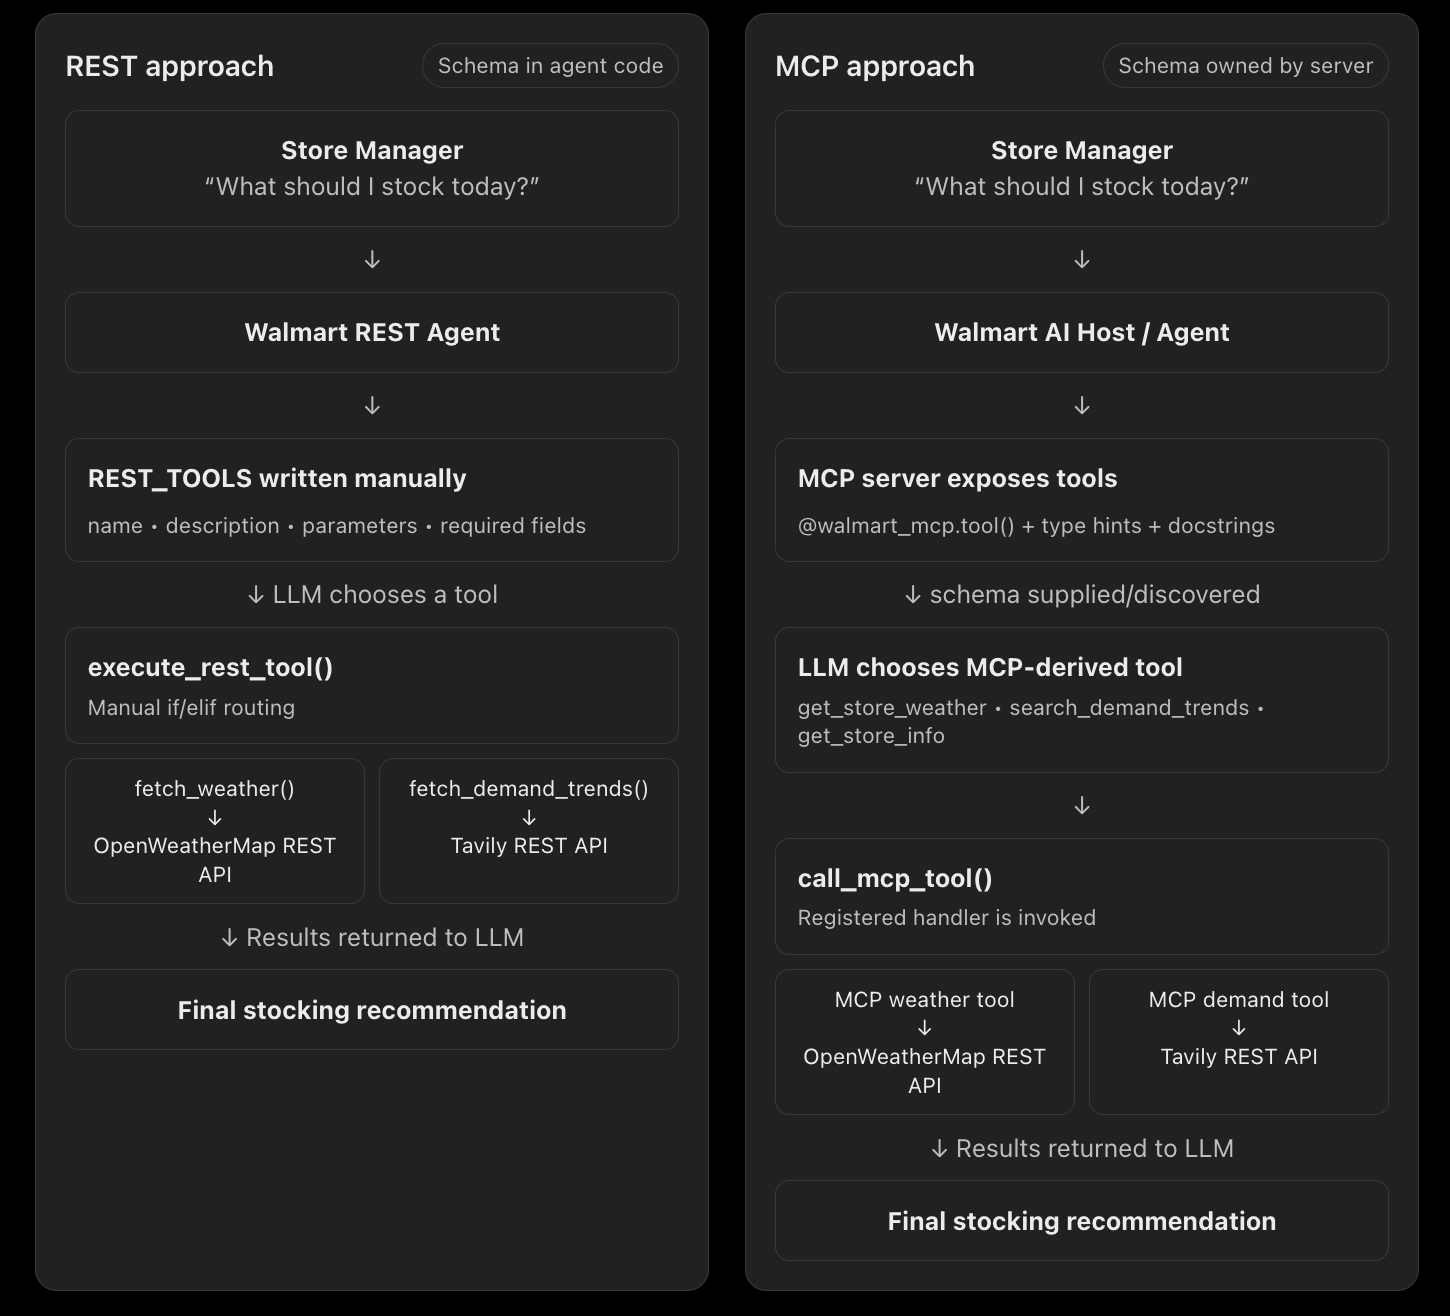

## Section 3: Framework Selection -- LangChain vs LangGraph vs Python-only

Framework selection is a TCO (Total Cost of Ownership) decision, not a features decision.
Every framework adds capabilities and adds cost: dependency risk, debugging complexity, version lock, and team learning curve.

All three implementations below use the **same real live data** (OpenWeatherMap + Tavily).
The difference is in how each framework manages state, control flow, and observability.

In [15]:
# This version uses plain Python only: no tool framework, no graph, just direct calls.
# It is the simplest option, but the developer must control every step manually.

# Python fetches weather
#         ↓
# Python fetches demand trends
#         ↓
# Python builds one context string
#         ↓
# LLM gets user question + that context
#         ↓
# LLM gives final answer

# Here the LLM does NOT dynamically choose or call tools. Python fetches all data first.

def python_only_agent(query: str) -> dict:
    # Python-only: full control, minimum abstraction.
    # Developer manually fetches data before the LLM call -- no dynamic tool calling.
    start = time.time()

    weather = fetch_weather(STORE_CITY)
    demand  = fetch_demand_trends(f'retail product demand {STORE_CITY} India', max_results=2)

    context = (
        f'Live weather for {STORE_CITY}: {json.dumps(weather)}. '
        f'Market demand signals: {demand["answer"][:400]}'
    )

    resp = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {
                'role': 'system',
                'content': (
                    f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                    f'Current live data: {context}'
                ),
            },
            {'role': 'user', 'content': query},
        ],
        temperature=0, max_tokens=400,
    )

    latency = time.time() - start
    ti, to  = resp.usage.prompt_tokens, resp.usage.completion_tokens
    return {
        'answer':      resp.choices[0].message.content.strip(),
        'latency_sec': round(latency, 2),
        'cost_usd':    round((ti * 0.15 + to * 0.60) / 1_000_000, 6),
        'framework':   'Python-only',
        'data_fetch':  'Manual pre-fetch (LLM cannot request more data dynamically)',
        'loc_approx':  30,
    }

py_result = python_only_agent(STORE_QUERY)
print('Python-only Agent Answer:')
print('-' * 60)
print(py_result['answer'][:450])
print('-' * 60)
print(f'Latency: {py_result["latency_sec"]}s | Framework: Python-only')
print(f'Note   : {py_result["data_fetch"]}')



 {'coord': {'lon': 77.6033, 'lat': 12.9762}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04n'}], 'base': 'stations', 'main': {'temp': 22.22, 'feels_like': 22.82, 'temp_min': 21.04, 'temp_max': 23.9, 'pressure': 1013, 'humidity': 89, 'sea_level': 1013, 'grnd_level': 914}, 'visibility': 10000, 'wind': {'speed': 3.09, 'deg': 250}, 'clouds': {'all': 82}, 'dt': 1788461758, 'sys': {'type': 2, 'id': 2109756, 'country': 'IN', 'sunrise': 1788482327, 'sunset': 1788526750}, 'timezone': 19800, 'id': 1277333, 'name': 'Bengaluru', 'cod': 200} 




[09/04/26 00:29:34] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=397515;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=136162;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1013\1013]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Python-only Agent Answer:
------------------------------------------------------------
Based on the current weather conditions in Bengaluru and the market demand signals, here are three specific product categories you should prioritize stocking today:

1. **Apparel and Outerwear**:
   - **Reasoning**: The current temperature in Bengaluru is 22.2°C with broken clouds, which suggests a mild and slightly cool climate. This weather is conducive to the sale of light jackets, sweaters, and other outerwear. Additionally, with the rising d
------------------------------------------------------------
Latency: 3.97s | Framework: Python-only
Note   : Manual pre-fetch (LLM cannot request more data dynamically)


In [16]:
pip install langchain langchain-openai --break-system-packages


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
# This version uses LangChain to manage tools and the agent loop for us.
# It reduces boilerplate, but adds another abstraction layer to learn and debug.
LC_AVAILABLE = False
lc_latency   = None

try:
    from langchain_openai import ChatOpenAI
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.tools import tool
    from langchain.agents import create_tool_calling_agent, AgentExecutor

    @tool
    def lc_get_weather(city: str) -> str:
        """Get real-time weather at a Walmart India store location for demand planning."""
        return json.dumps(fetch_weather(city))

    @tool
    def lc_search_trends(query: str) -> str:
        """Search for real-time retail demand trends and market signals using Tavily."""
        return json.dumps(fetch_demand_trends(query, max_results=2))

    lc_llm   = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    lc_tools = [lc_get_weather, lc_search_trends]

    lc_prompt = ChatPromptTemplate.from_messages([
        ('system',
         f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
         'Use tools to retrieve live data before making recommendations.'),
        ('human', '{input}'),
        ('placeholder', '{agent_scratchpad}'),
    ])

    lc_agent    = create_tool_calling_agent(lc_llm, lc_tools, lc_prompt)
    lc_executor = AgentExecutor(agent=lc_agent, tools=lc_tools, verbose=True, max_iterations=6)

    start       = time.time()
    lc_response = lc_executor.invoke({'input': STORE_QUERY})
    lc_latency  = time.time() - start

    print('LangChain Agent Answer (real tools via LCEL + AgentExecutor):')
    print('-' * 60)
    print(lc_response['output'][:450])
    print('-' * 60)
    print(f'Latency: {lc_latency:.2f}s | Framework: LangChain')
    LC_AVAILABLE = True

except ImportError as e:
    print(f'LangChain not installed: {e}')
    print('Install: pip install langchain langchain-openai --break-system-packages')



> Entering new AgentExecutor chain...


[09/04/26 00:47:21] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=676784;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=94269;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1013\1013]8;;\
                             "HTTP/1.1 200 OK"                                                                     


Invoking: `lc_get_weather` with `{'city': 'Bengaluru'}`




 {'coord': {'lon': 77.6033, 'lat': 12.9762}, 'weather': [{'id': 500, 'main': 'Rain', 'description': 'light rain', 'icon': '10n'}], 'base': 'stations', 'main': {'temp': 21.83, 'feels_like': 22.42, 'temp_min': 21.04, 'temp_max': 23.9, 'pressure': 1013, 'humidity': 90, 'sea_level': 1013, 'grnd_level': 914}, 'visibility': 10000, 'wind': {'speed': 3.17, 'deg': 262, 'gust': 6.15}, 'rain': {'1h': 1}, 'clouds': {'all': 82}, 'dt': 1788462541, 'sys': {'type': 2, 'id': 2109756, 'country': 'IN', 'sunrise': 1788482327, 'sunset': 1788526750}, 'timezone': 19800, 'id': 1277333, 'name': 'Bengaluru', 'cod': 200} 


{"city": "Bengaluru", "country": "IN", "temperature_c": 21.8, "feels_like_c": 22.4, "humidity_pct": 90, "condition": "light rain", "condition_main": "Rain", "wind_speed_ms": 3.17, "pressure_hpa": 1013}
Invoking: `lc_search_trends` with `{'query': 'Bengaluru'}`


{"answer": "Bengaluru is the capital of Karnataka state in southern Ind

[09/04/26 00:47:24] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=198162;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=846250;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1013\1013]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories to prioritize stocking today:

1. **Rain Gear (Umbrellas, Raincoats, and Waterproof Bags)**
   - **Weather Support**: The current weather in Bengaluru indicates light rain with a temperature of around 21.8°C and high humidity (90%). This suggests that customers are likely to seek rain gear to stay dry and comfortable while commuting or going about their daily activities.
   - **Market Demand**: Given the rainy conditions, there is typically an increase in demand for umbrellas and raincoats. Stocking these items will cater to immediate customer needs.

2. **Comfort Foods (Snacks, Instant Noodles, and Hot Beverages)**
   - **Weather Support**: The cool and rainy weather often leads people to crave comfort foods that are warm and satisfying. Items like instant noodles, hot beverages (tea and coffee), and snacks are popular choices during such weather.
   - **Market De

In [18]:
STORE_QUERY

"I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation."

In [22]:
# %pip install langgraph --break-system-packages -q

In [23]:
# This version uses LangGraph, which is built for step-by-step workflows with shared state.
# It is more verbose than LangChain, but it makes control flow easier to see.
LG_AVAILABLE = False
lg_latency   = None

try:
    from langgraph.graph import StateGraph, END

    class WalmartState(TypedDict):
        # Shared state passed from one graph step to the next.
        query:        str
        weather_data: dict
        demand_data:  dict
        answer:       str
        route:        str

    def classify_node(state: WalmartState) -> WalmartState:
        # Decide whether the query needs weather only, demand only, or both.
        q = state['query'].lower()
        if any(w in q for w in ['weather', 'rain', 'temperature', 'heat', 'cold', 'wind', 'humid']):
            state['route'] = 'weather_only'
        elif any(w in q for w in ['trend', 'demand', 'market', 'popular', 'sell', 'sales']):
            state['route'] = 'demand_only'
        else:
            state['route'] = 'full_analysis'
        return state

    def weather_node(state: WalmartState) -> WalmartState:
        # Fetch weather and save it in the shared workflow state.
        state['weather_data'] = fetch_weather(STORE_CITY)
        return state

    def demand_node(state: WalmartState) -> WalmartState:
        # Fetch demand signals and save them in the shared workflow state.
        state['demand_data'] = fetch_demand_trends(
            f'retail grocery product demand {STORE_CITY} India',
            max_results=2,
        )
        return state

    def synthesise_node(state: WalmartState) -> WalmartState:
        # Turn the accumulated live data into the final natural-language answer.
        parts = []
        if state.get('weather_data'):
            parts.append(f'Live weather: {json.dumps(state["weather_data"])}')
        if state.get('demand_data'):
            answer = state['demand_data'].get('answer', '')
            parts.append(f'Market demand signals: {answer[:350]}')
        context = ' | '.join(parts) if parts else 'No live data fetched.'

        resp = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[
                {
                    'role': 'system',
                    'content': (
                        f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                        f'Live data from the workflow: {context}'
                    ),
                },
                {'role': 'user', 'content': state['query']},
            ],
            temperature=0, max_tokens=400,
        )
        state['answer'] = resp.choices[0].message.content.strip()
        return state

    def route_after_classify(state: WalmartState) -> str:
        # Send the workflow to the next step based on the earlier classification.
        return state['route']

    workflow = StateGraph(WalmartState)
    workflow.add_node('classify',    classify_node)
    workflow.add_node('get_weather', weather_node)
    workflow.add_node('get_demand',  demand_node)
    workflow.add_node('synthesise',  synthesise_node)

    workflow.set_entry_point('classify')
    workflow.add_conditional_edges('classify', route_after_classify, {
        'weather_only':  'get_weather',
        'demand_only':   'get_demand',
        'full_analysis': 'get_weather',
    })
    workflow.add_edge('get_weather', 'get_demand')
    workflow.add_edge('get_demand',  'synthesise')
    workflow.add_edge('synthesise',  END)

    lg_app = workflow.compile()

    start = time.time()
    lg_result = lg_app.invoke({
        'query':        STORE_QUERY,
        'weather_data': {},
        'demand_data':  {},
        'answer':       '',
        'route':        '',
    })
    lg_latency = time.time() - start

    print('LangGraph Agent Answer (real stateful workflow):')
    print('-' * 60)
    print(lg_result['answer'][:450])
    print('-' * 60)
    print(f'Latency  : {lg_latency:.2f}s | Framework: LangGraph')
    print(f'Route    : classify -> {lg_result["route"]} -> get_weather -> get_demand -> synthesise')
    w = lg_result['weather_data']
    d = lg_result['demand_data']
    print(f'Weather  : {w.get("condition","N/A")} at {w.get("temperature_c","N/A")} C, humidity {w.get("humidity_pct","N/A")}%')
    print(f'Demand   : {len(d.get("results",[]))} market articles retrieved')
    LG_AVAILABLE = True

except ImportError as e:
    print(f'LangGraph not installed: {e}')
    print('Install: pip install langgraph --break-system-packages')



 {'coord': {'lon': 77.6033, 'lat': 12.9762}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04n'}], 'base': 'stations', 'main': {'temp': 21.71, 'feels_like': 22.29, 'temp_min': 21.04, 'temp_max': 22.9, 'pressure': 1012, 'humidity': 90, 'sea_level': 1012, 'grnd_level': 914}, 'visibility': 10000, 'wind': {'speed': 3.19, 'deg': 267, 'gust': 6.52}, 'clouds': {'all': 65}, 'dt': 1788464282, 'sys': {'type': 2, 'id': 2109756, 'country': 'IN', 'sunrise': 1788482327, 'sunset': 1788526750}, 'timezone': 19800, 'id': 1277333, 'name': 'Bengaluru', 'cod': 200} 




[09/04/26 01:09:26] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=252068;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=173129;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1013\1013]8;;\
                             "HTTP/1.1 200 OK"                                                                     

LangGraph Agent Answer (real stateful workflow):
------------------------------------------------------------
Based on the current weather conditions in Bengaluru and the market demand signals, here are three specific product categories you should prioritize stocking today:

1. **Fresh Produce (Fruits and Vegetables)**:
   - **Reasoning**: The current weather in Bengaluru is characterized by broken clouds and high humidity (90%). Such conditions often lead to a preference for fresh and healthy food options, as consumers tend to seek refreshing items like
------------------------------------------------------------
Latency  : 6.76s | Framework: LangGraph
Route    : classify -> weather_only -> get_weather -> get_demand -> synthesise
Weather  : broken clouds at 21.7 C, humidity 90%
Demand   : 2 market articles retrieved


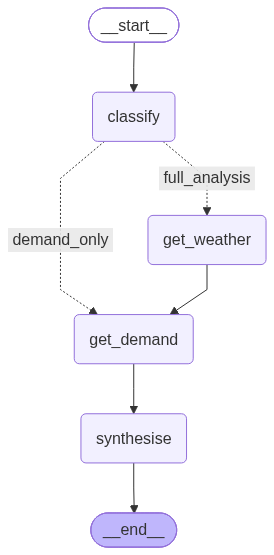

In [24]:
# Draw the workflow graph so the LangGraph control flow is visible.
if LG_AVAILABLE:
    from IPython.display import Image, display
    display(Image(lg_app.get_graph().draw_mermaid_png()))

## Section 4: Build vs Buy Rubric

Build vs Buy is the decision that precedes framework selection.
If the answer is Buy, you are evaluating vendors, not frameworks.

The rubric scores five axes (each 1-3):
- **Differentiation:** Does this component create competitive advantage?
- **Complexity:** How hard is it to build and maintain at scale?
- **Vendor risk:** How much lock-in does buying create?
- **Speed to value:** How fast does buy vs build deliver the first working version?
- **Cost advantage:** Is build cost (engineering time) lower or higher than buy cost (licensing + integration)?

Score >= 11 = **Build** | Score <= 8 = **Buy** | 9-10 = **Buy + Customize**

In [25]:
# Score each platform decision with the same simple rubric.
# This makes the Build vs Buy choice more explicit and repeatable.
def build_or_buy(component: str, scores: dict) -> dict:
    # scores: each axis is 1=Buy-favoured, 2=Neutral, 3=Build-favoured
    total = sum(scores.values())
    if total >= 11:
        decision  = 'BUILD'
        rationale = 'Component creates differentiation or vendor risk is too high to accept'
    elif total <= 8:
        decision  = 'BUY'
        rationale = 'Commodity capability; vendor delivers faster and cheaper'
    else:
        decision  = 'BUY + CUSTOMIZE'
        rationale = 'Start with vendor solution, extend where differentiation matters'
    return {
        'component': component, 'scores': scores,
        'total': total, 'decision': decision, 'rationale': rationale,
    }

components = [
    ('Orchestration framework (LangGraph)', {
        'differentiation': 1, 'complexity': 2,
        'vendor_risk': 2,     'speed_advantage': 3, 'cost_advantage': 1,
    }),
    ('RAG vector store (Chroma vs Pinecone)', {
        'differentiation': 1, 'complexity': 3,
        'vendor_risk': 1,     'speed_advantage': 1, 'cost_advantage': 2,
    }),
    ('Walmart domain knowledge base (Q&A dataset)', {
        'differentiation': 3, 'complexity': 1,
        'vendor_risk': 3,     'speed_advantage': 1, 'cost_advantage': 3,
    }),
    ('LLM inference (OpenAI API vs self-hosted)', {
        'differentiation': 1, 'complexity': 3,
        'vendor_risk': 2,     'speed_advantage': 1, 'cost_advantage': 1,
    }),
    ('MCP tool server (FastMCP vs custom HTTP)', {
        'differentiation': 1, 'complexity': 2,
        'vendor_risk': 1,     'speed_advantage': 3, 'cost_advantage': 2,
    }),
]

results = [build_or_buy(name, scores) for name, scores in components]

print(f'{"Component":<48} {"Score":>6} {"Decision":>18}')
print('-' * 74)
for r in results:
    print(f'{r["component"]:<48} {r["total"]:>6} {r["decision"]:>18}')

print()
for r in results:
    print(f'{r["component"]}:')
    print(f'  {r["decision"]}: {r["rationale"]}')

Component                                         Score           Decision
--------------------------------------------------------------------------
Orchestration framework (LangGraph)                   9    BUY + CUSTOMIZE
RAG vector store (Chroma vs Pinecone)                 8                BUY
Walmart domain knowledge base (Q&A dataset)          11              BUILD
LLM inference (OpenAI API vs self-hosted)             8                BUY
MCP tool server (FastMCP vs custom HTTP)              9    BUY + CUSTOMIZE

Orchestration framework (LangGraph):
  BUY + CUSTOMIZE: Start with vendor solution, extend where differentiation matters
RAG vector store (Chroma vs Pinecone):
  BUY: Commodity capability; vendor delivers faster and cheaper
Walmart domain knowledge base (Q&A dataset):
  BUILD: Component creates differentiation or vendor risk is too high to accept
LLM inference (OpenAI API vs self-hosted):
  BUY: Commodity capability; vendor delivers faster and cheaper
MCP tool server (F

In [26]:
# Pull the earlier findings into one recommended production stack for Walmart.
WALMART_RETAIL_ASSISTANT_STACK = {
    'use_case':    'Walmart India Retail Assistant',
    'description': 'AI agent for store associates: inventory, policies, demand planning, supplier queries',
    'scale':       '50,000+ queries/day across 4,700 stores',
    'slo':         'P95 latency < 3s, availability 99.5%, error rate < 1%',
    'protocol': {
        'choice':    'MCP (FastMCP)',
        'rationale': (
            'Standardised tool schema enables reuse across store ops, supply chain, and HR agents '
            'without rewriting tool descriptions. MCP server versioning handles quarterly policy '
            'updates with zero changes to agent code. Demonstrated live in this notebook.'
        ),
    },
    'framework': {
        'choice':    'LangGraph',
        'rationale': (
            'Multi-step workflows (classify -> weather -> demand -> synthesise -> escalate) require '
            'explicit typed state management. LangGraph checkpointing supports human-in-the-loop '
            'for supplier reorder approvals. Demonstrated live with real data in this notebook.'
        ),
    },
    'build_buy': {
        'orchestration':   'Build with LangGraph (open-source, score 9 -- BUY+CUSTOMIZE)',
        'mcp_server':      'Build with FastMCP (score 9 -- BUY+CUSTOMIZE, open-source)',
        'vector_store':    'Buy Pinecone (scale + managed SLA, score 8 -- BUY)',
        'knowledge_base':  'Build internally (Walmart IP, cannot outsource, score 11 -- BUILD)',
        'llm_inference':   'Buy OpenAI API for initial scale; re-evaluate at 100k+ daily queries',
    },
    'evaluation_gate': 'Task Success Rate >= 0.80 on 100-case Walmart golden dataset before production',
}

print('Walmart Retail Assistant -- Recommended Production Stack')
print('=' * 58)
for section, content in WALMART_RETAIL_ASSISTANT_STACK.items():
    if isinstance(content, dict):
        print(f'\n{section.upper()}:')
        for k, v in content.items():
            print(f'  {k}: {v}')
    else:
        print(f'{section}: {content}')

Walmart Retail Assistant -- Recommended Production Stack
use_case: Walmart India Retail Assistant
description: AI agent for store associates: inventory, policies, demand planning, supplier queries
scale: 50,000+ queries/day across 4,700 stores
slo: P95 latency < 3s, availability 99.5%, error rate < 1%

PROTOCOL:
  choice: MCP (FastMCP)
  rationale: Standardised tool schema enables reuse across store ops, supply chain, and HR agents without rewriting tool descriptions. MCP server versioning handles quarterly policy updates with zero changes to agent code. Demonstrated live in this notebook.

FRAMEWORK:
  choice: LangGraph
  rationale: Multi-step workflows (classify -> weather -> demand -> synthesise -> escalate) require explicit typed state management. LangGraph checkpointing supports human-in-the-loop for supplier reorder approvals. Demonstrated live with real data in this notebook.

BUILD_BUY:
  orchestration: Build with LangGraph (open-source, score 9 -- BUY+CUSTOMIZE)
  mcp_server: 

## Summary

You have built and compared production-grade AI protocol and framework implementations using **live external data**:

- **Protocol:** REST vs MCP -- both called real OpenWeatherMap and Tavily APIs. MCP wins for multi-agent reuse at Walmart scale because tool schemas live on the server, not in every agent's code.
- **Framework:** All three frameworks fetched real weather and real demand signals and produced grounded recommendations from live data. LangGraph's explicit typed state is the right choice for the Walmart Retail Assistant's multi-step workflow.
- **Build vs Buy:** Quantified per component. Domain knowledge base is always BUILD. Everything else is BUY or BUY+CUSTOMIZE using open-source tools.

**Key principle:** These decisions compound. Wrong protocol forces a framework rewrite. Wrong Build vs Buy wastes 3-6 months of engineering. Score the rubric before writing a single line of production code.

**Your deliverable:** `framework_selection_matrix.txt` -- ARB-ready with live latency and cost data from this session.

**Next:** IN04 -- Agent Design Principles